In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

from analysis.load_run_data import load_run_data


# Load run

In [3]:
data = load_run_data(
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2025-10-29/16-17-39/analysis/cartpole-swingup'
)

Found 20 episode directories in /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/outputs/2025-10-29/16-17-39/analysis/cartpole-swingup
Loaded 20 episodes


Loaded 20 planning episodes
Loaded run summary


# Analyze activations

In [4]:
def extract_variables(data, variables=['latent_states', 'observations']):
    out = {var: [] for var in variables}
    episodes = data.get('episodes', [])
    for ep in episodes:
        d = ep['data']
        for var in variables:
            arr = d.get(var)
            arr = np.array(arr)
            # Handle special cases for latents and obs for compatibility
            if var == 'latent_states' and arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr.squeeze(1)
            if var == 'observations' and arr.ndim == 1:
                arr = arr.reshape(-1, 1)
            out[var].append(arr)
    return out

In [5]:
vars_run = extract_variables(
    data, variables=['latent_states', 'observations', 'actions'])

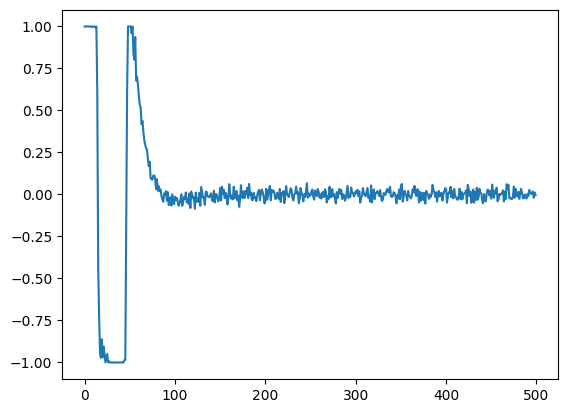

In [6]:
plt.plot(vars_run['actions'][0])

## Basic stats on the episodes

## What latents are most important for each variable?

In [7]:
# Fit linear regressors from latents to observations
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import r2_score
import numpy as np

In [8]:
def fit_lasso_and_r2(latents_list, obs_list, alpha=0.001):
    models = []
    r2_scores = []
    y_preds = []
    coefs_list = []
    for X, y in zip(latents_list, obs_list):
        model = Lasso(alpha=alpha)
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        models.append(model)
        coefs_list.append(model.coef_)
        r2_scores.append(r2)
        y_preds.append(y_pred)
    return models, r2_scores, y_preds, coefs_list


# Example usage:
# models, r2_scores, y_preds = fit_lasso_and_r2(latents_list, obs_list)

In [9]:
models, r2_scores, y_preds, coefs_list = fit_lasso_and_r2(
    vars_run['latent_states'],
    vars_run['observations'],
)

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.199e-01, tolerance: 8.446e-02
  model = cd_fast.enet_coordinate_descent(
/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.803e-02, tolerance: 8.482e-02
  model = cd_fast.enet_coordinate_descent(


In [10]:
import matplotlib.pyplot as plt
import numpy as np


def plot_lasso_coefs(coefs_list, max_per_row=2):
    """
    For each set of coefficients in coefs_list, plot nonzero lasso coefficients as a scatter plot.
    Up to `max_per_row` plots per row.
    """
    n_plots = len(coefs_list)
    n_cols = max_per_row
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows,
                             n_cols,
                             figsize=(5 * n_cols, 4 * n_rows),
                             squeeze=False,
                             dpi=300)
    for idx, coef in enumerate(coefs_list):
        ax = axes[idx // n_cols, idx % n_cols]

        nz_lats, nz_outs = np.nonzero(coef)
        vals = coef[nz_lats, nz_outs]
        sc = ax.scatter(nz_outs,
                        nz_lats,
                        s=30,
                        c=vals,
                        cmap="coolwarm",
                        marker='s')
        ax.set_xlabel("Latent dimension")
        ax.set_ylabel("Observed dimension")
        ax.set_title(f"Lasso nonzero coeffs: Output {idx}")
        #ax.set_xticks([])
        ax.set_yticks([0, 1, 2, 3, 4])
        plt.colorbar(ax.collections[0], ax=ax, label="Coefficient value")

    # Hide unused axes
    for j in range(idx + 1, n_rows * n_cols):
        fig.delaxes(axes[j // n_cols, j % n_cols])
    plt.tight_layout()
    plt.show()


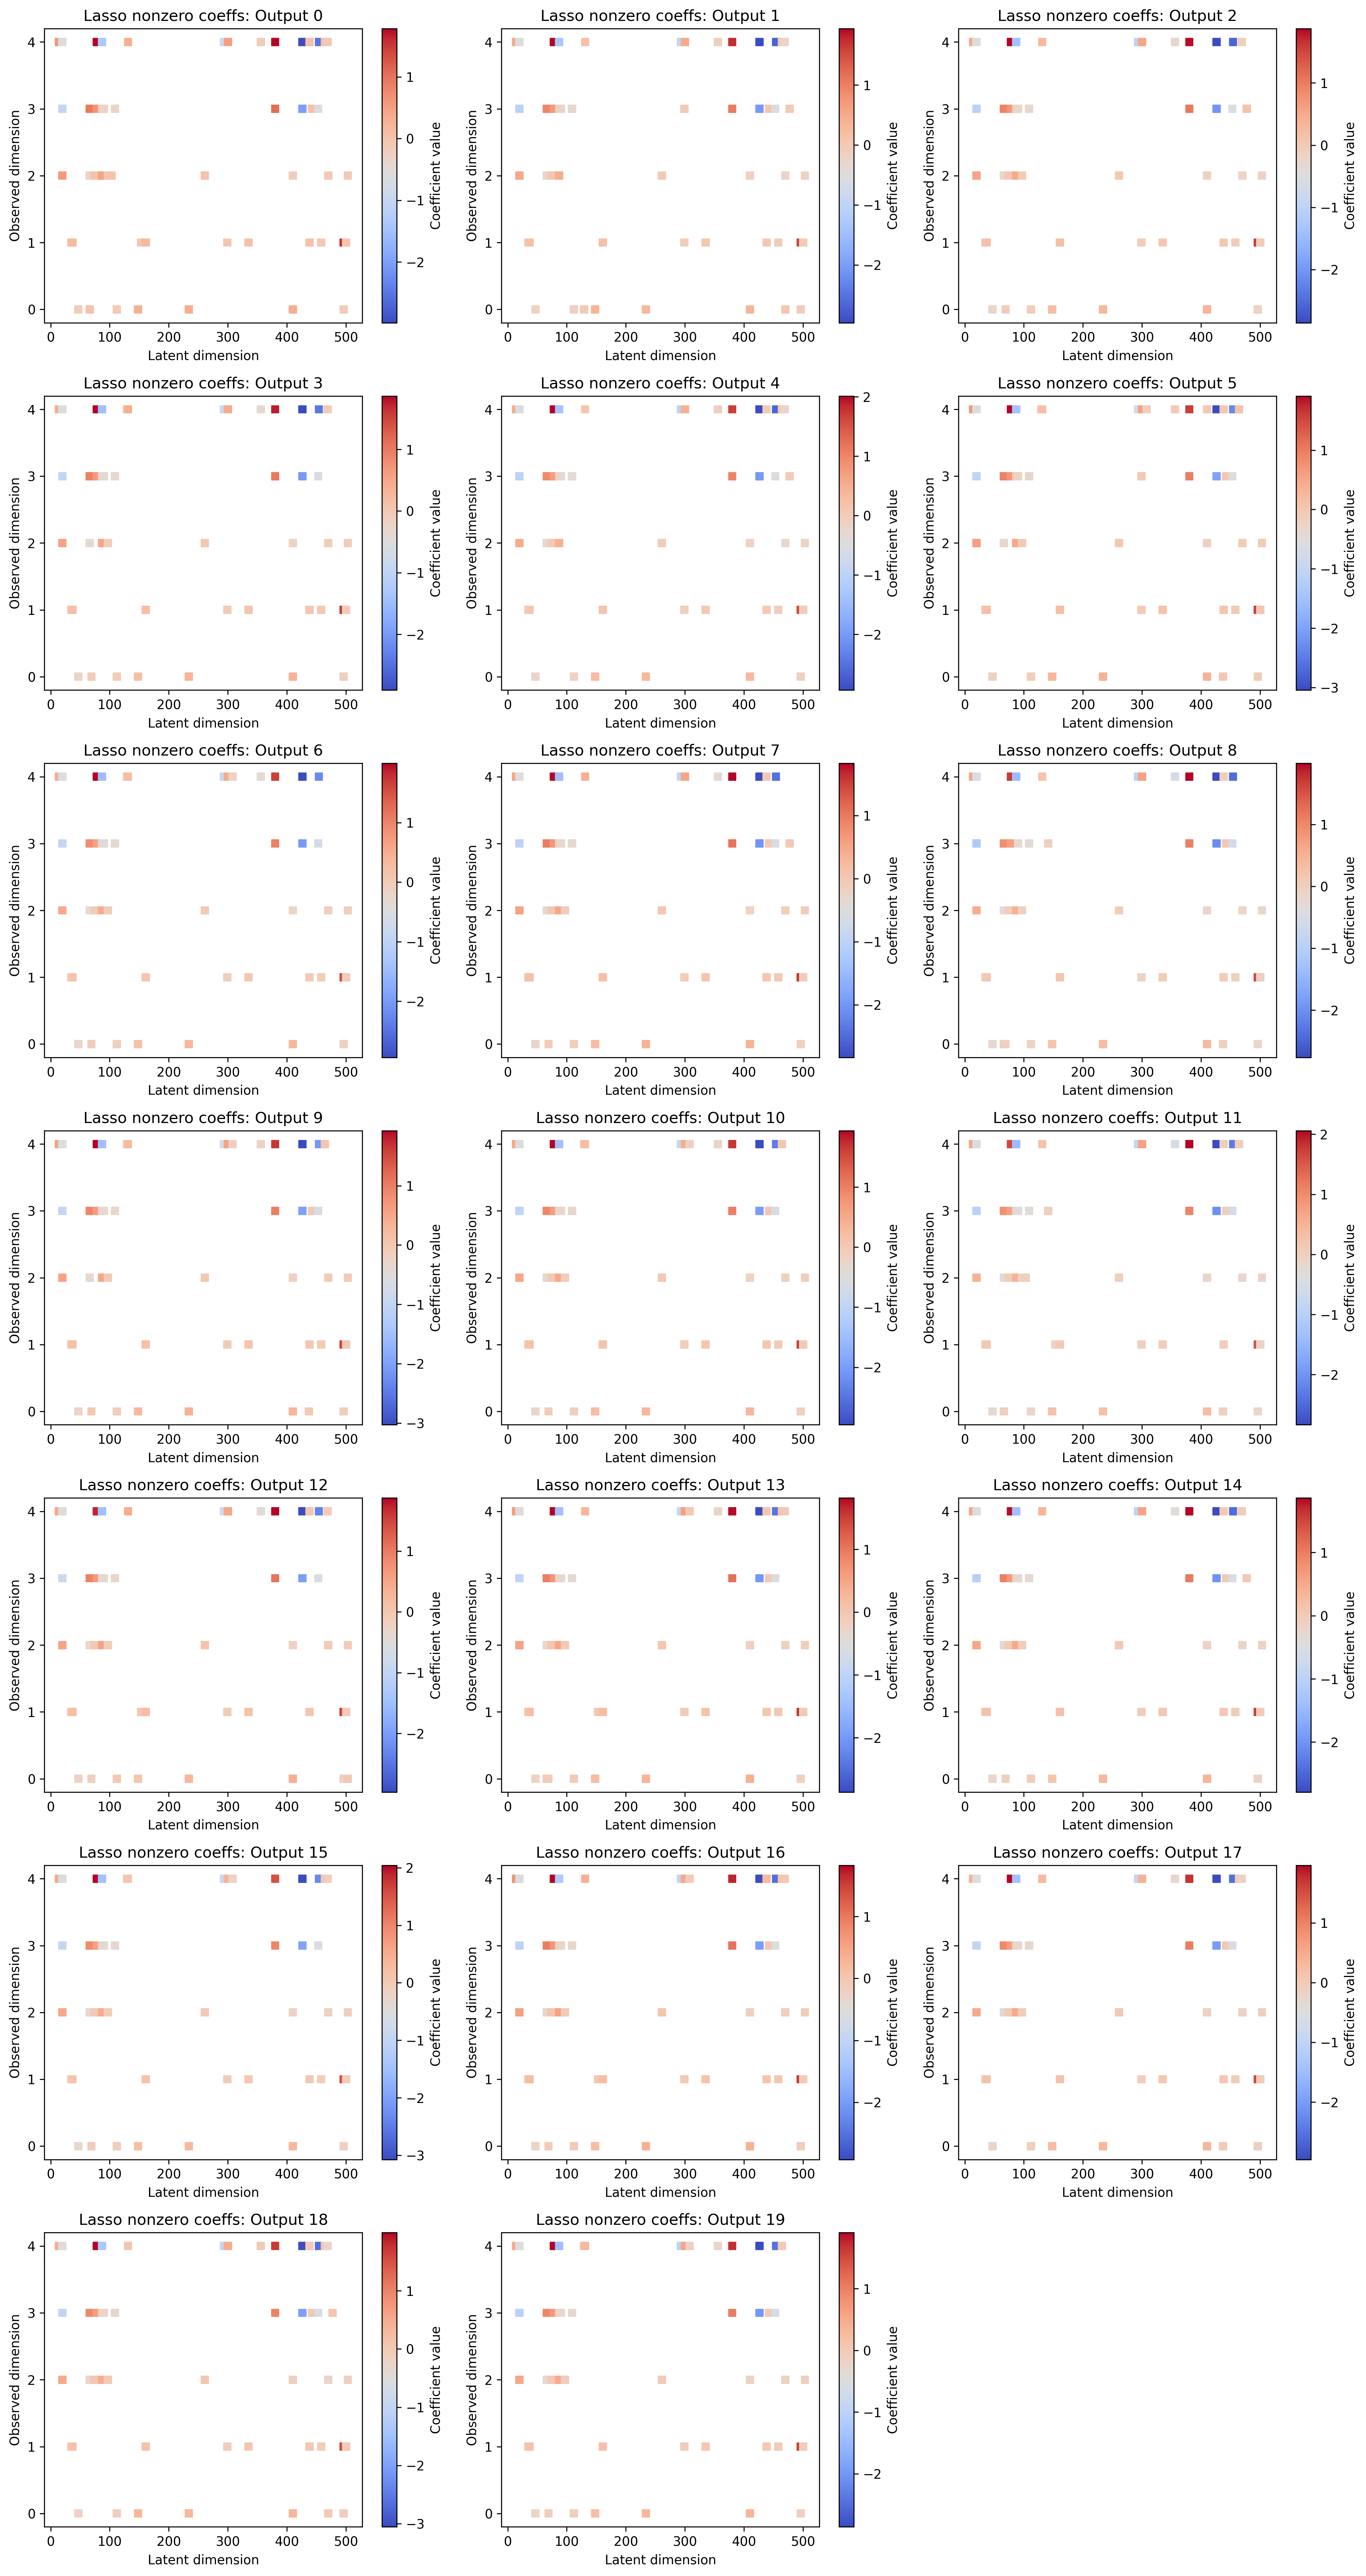

In [11]:
plot_lasso_coefs(coefs_list, max_per_row=3)

## Low dimensional structure in latents

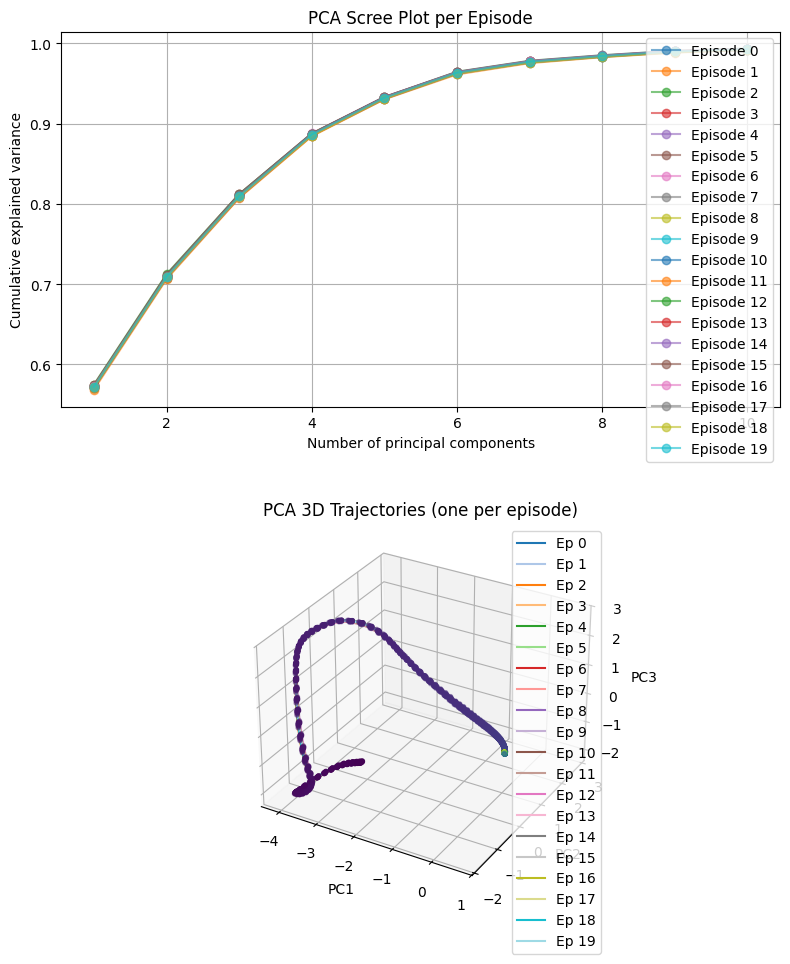

In [12]:
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d import Axes3D  # ensure 3d is imported for projection='3d'

episode_pc_results = []
episode_pca_trajectories = []

# Go through each episode, compute PCA, and store results
for ep_idx, episode in enumerate(data['episodes']):
    latents_ep = vars_run['latent_states'][ep_idx]
    n_lat, lat_dim = latents_ep.shape

    this_pca = PCA(n_components=min(10, lat_dim))
    latents_pca = this_pca.fit_transform(latents_ep)
    explained_variance = this_pca.explained_variance_ratio_
    episode_pc_results.append({
        'ep_idx': ep_idx,
        'explained_variance': explained_variance,
        'pca_model': this_pca,
        'latents_pca': latents_pca
    })

    # Save 3D PCA trajectory if enough dims
    if lat_dim >= 3:
        pca_3d = PCA(n_components=3)
        latents_pca_3d = pca_3d.fit_transform(latents_ep)
    else:
        latents_pca_3d = None
    episode_pca_trajectories.append({
        'ep_idx': ep_idx,
        'latents_pca_3d': latents_pca_3d,
    })

# Make stacked (vertical) plots: one below the other

fig = plt.figure(figsize=(8, 10))

# Scree plot: explained variance (top)
ax1 = fig.add_subplot(2, 1, 1)
for result in episode_pc_results:
    ax1.plot(np.arange(1,
                       len(result['explained_variance']) + 1),
             np.cumsum(result['explained_variance']),
             marker='o',
             label=f'Episode {result["ep_idx"]}',
             alpha=0.6)
ax1.set_xlabel("Number of principal components")
ax1.set_ylabel("Cumulative explained variance")
ax1.set_title("PCA Scree Plot per Episode")
ax1.grid(True)
ax1.legend()

# 3D PCA trajectories: one per episode (bottom)
ax2 = fig.add_subplot(2, 1, 2, projection='3d')
num_eps = len(episode_pca_trajectories)
colors = plt.cm.tab20(np.linspace(0, 1, num_eps))
for i, traj in enumerate(episode_pca_trajectories):
    arr = traj['latents_pca_3d']
    if arr is not None:
        ax2.plot(arr[:, 0],
                 arr[:, 1],
                 arr[:, 2],
                 label=f'Ep {traj["ep_idx"]}',
                 color=colors[i])
        ax2.scatter(
            arr[:, 0],
            arr[:, 1],
            arr[:, 2],
            s=9,  # Make scatter points just a bit larger
            alpha=0.5,
            c=np.arange(len(arr)),
            cmap='viridis')
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_zlabel("PC3")
ax2.set_title("PCA 3D Trajectories (one per episode)")
ax2.legend(loc='best')

plt.tight_layout()
plt.show()


In [13]:
data['episodes'][0]['data'].keys()

dict_keys(['observations', 'actions', 'rewards', 'dones', 'latent_states', 'timesteps'])

In [14]:
data['planning'][0]['data'].keys()

dict_keys(['planning_steps', 'num_steps'])

In [15]:
planning_steps = data['planning'][0]['data']['planning_steps']

In [16]:
planning_steps[0].keys()

dict_keys(['timestep', 'initial_latent', 'selected_action', 'num_iterations', 'iterations'])

In [17]:
planning_steps[0]['iterations'][0].keys()

dict_keys(['iteration', 'mean_actions', 'std_actions', 'elite_actions', 'elite_values'])

In [18]:
planning_steps[0]['iterations'][0]['elite_values']

array([110.19974 , 110.1996  , 110.19924 , 110.19913 , 110.19881 ,
       110.19825 , 110.19801 , 110.197945, 110.1965  , 110.19574 ,
       110.195526, 110.19451 , 110.193726, 110.193245, 110.192375,
       110.19184 , 110.190865, 110.1908  , 110.19033 , 110.18989 ,
       110.18989 , 110.1897  , 110.18861 , 110.18848 , 110.18522 ,
       110.184265, 110.184105, 110.184044, 110.18386 , 110.18188 ,
       110.18158 , 110.17838 , 110.17784 , 110.177   , 110.17223 ,
       110.1716  , 110.159096, 110.15473 , 110.132   , 110.12997 ,
       110.12475 , 110.07546 , 110.04427 , 110.02026 , 110.01843 ,
       110.015526, 109.98258 , 109.95704 , 109.9177  , 109.855774,
       109.81979 , 109.81398 , 109.80243 , 109.73181 , 109.68386 ,
       109.67603 , 109.62715 , 109.620056, 109.562805, 109.554344,
       109.54173 , 109.43865 , 109.4343  , 109.41385 ], dtype=float32)

## Experiments

In [19]:
from hydra import initialize, compose
import os
from common.activation_patcher import ActivationPatcher
from common.parser import parse_cfg
from envs import make_env
import numpy as np
from tdmpc2 import TDMPC2
from common.episode_data_recorder import EpisodeDataRecorder
from common.planning_data_recorder import PlanningDataRecorder
from envs import make_env
from recording_tdmpc2 import RecordingTDMPC2
from omegaconf import OmegaConf

/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/glfw/__init__.py:914: GLFWError: (65544) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)


### Sufficiency and necessity of latents

##TODO:

- add video saving to recorder
- add replacement, not only ablation


In [20]:
# def run_episode(env, agent, max_steps=200):
#     obs = env.reset()
#     done = False
#     total_reward = 0
#     t = 0

#     while not done and t < max_steps:
#         action = agent.act(obs, t0=(t == 0), eval_mode=True)
#         obs, reward, done, info = env.step(action)
#         total_reward += reward
#         t += 1

#     return total_reward


def run_episode(env, agent, max_steps=200):
    obs = env.reset()
    done = False
    total_reward = 0
    t = 0

    # Run episode
    while not done and t < max_steps:

        # Act (agent records planning data internally if enabled)
        action = agent.act(obs, t0=(t == 0), eval_mode=True)

        # Step environment
        next_obs, reward, done, info = env.step(action)

        # Get latent state from agent for episode recording
        latent_state = agent.get_last_latent()

        # Record episode data
        agent.episode_recorder.record_step(obs=obs,
                                           action=action,
                                           reward=reward,
                                           done=done,
                                           latent_state=latent_state)

        # Update for next step
        obs = next_obs
        total_reward += reward
        t += 1

    return total_reward

In [51]:
abs_config_dir = "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2"
os.chdir(os.path.dirname(abs_config_dir))
config_dir = "tdmpc2"

override_cfg = dict(
    task='cartpole-swingup',
    checkpoint=
    '/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/ckpts/cartpole-swingup-3.pt',
    obs='state',
    seed=1,
    compile=False,
    mpc=True,
    multitask=False,
    model_size=5,
)

with initialize(config_path=config_dir, version_base=None):
    # config_name is the base name of the YAML file (without .yaml extension)
    cfg = compose(config_name="config")
    cfg = OmegaConf.merge(cfg, override_cfg)
    cfg = parse_cfg(cfg)

In [52]:
env = make_env(cfg)

# Create recorders for this episode
episode_recorder = EpisodeDataRecorder(cfg)
planning_recorder = PlanningDataRecorder(save_full_trajectories=False)

agent = RecordingTDMPC2(cfg,
                        episode_recorder=episode_recorder,
                        planning_recorder=planning_recorder)

if Path(cfg.checkpoint).exists():
    print(f"   Loading checkpoint: {cfg.checkpoint}")
    agent.load(cfg.checkpoint)
else:
    print(f"   Warning: Checkpoint not found: {cfg.checkpoint}")
    print("   Using untrained agent")

EpisodeDataRecorder initialized. No save directory provided.
PlanningDataRecorder initialized (minimal mode). Saving to: analysis/planning
Episode length: 500
Discount factor: 0.99
RecordingTDMPC2 initialized:
  Episode recording: enabled
  Planning recording: enabled
   Loading checkpoint: /home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/ckpts/cartpole-swingup-3.pt


### Ablate all the non-important latents

In [53]:
# Find indices of nonzero latents in coefs_list[0]
nonzero_latent_indices = np.where(coefs_list[0].T != 0)[0]
important_latents = np.unique(nonzero_latent_indices)
non_important_latents = np.setdiff1d(np.arange(coefs_list[0].shape[1]),
                                     important_latents)

In [54]:
len(important_latents), len(non_important_latents)

(39, 473)

In [55]:
patcher = ActivationPatcher(agent.model, modules_to_hook=['encoder_output'])

Setting up hooks for encoder_output
ActivationPatcher initialized with hooks on:
  - encoder_output


In [56]:
patcher.clear_interventions()
patcher.add_ablation('encoder_output', dims=non_important_latents)

Cleared all interventions
Added intervention at: encoder_output
  Ablating dimensions: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  15  16  17  18
  19  21  22  23  24  25  26  27  28  29  30  31  32  33  34  36  38  39
  40  41  42  43  44  45  46  48  49  50  51  52  53  54  55  56  57  58
  59  60  61  62  63  64  65  67  68  69  70  71  72  73  75  76  77  79
  80  81  82  83  84  85  86  88  89  91  92  93  94  95  96  98  99 100
 101 102 104 105 106 107 108 110 111 113 114 115 116 117 118 119 120 121
 122 123 124 125 126 127 128 129 130 132 133 134 135 136 137 138 139 140
 141 142 143 144 145 146 147 149 150 151 152 154 155 156 157 158 159 160
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 235 236 237 238 239 240 241 242 243 

In [57]:
ablation_reward = run_episode(env, agent)
print(f"   Ablation reward: {ablation_reward:.2f}")

   Ablation reward: 99.17


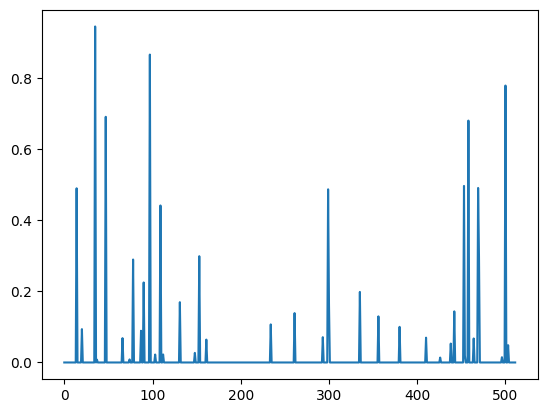

In [58]:
plt.plot(agent.episode_recorder.episode_data['latent_states'][0][0])

In [59]:
agent.episode_recorder.episode_data['latent_states'][0][0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.49005303,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.09381199, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.9453548 , 0.        , 0.00804598, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.6911879 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.0684814 , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00858

In [66]:
obs_stacked = np.stack(agent.episode_recorder.episode_data['observations'],
                       axis=0)
action_stacked = np.stack(agent.episode_recorder.episode_data['actions'],
                          axis=0)


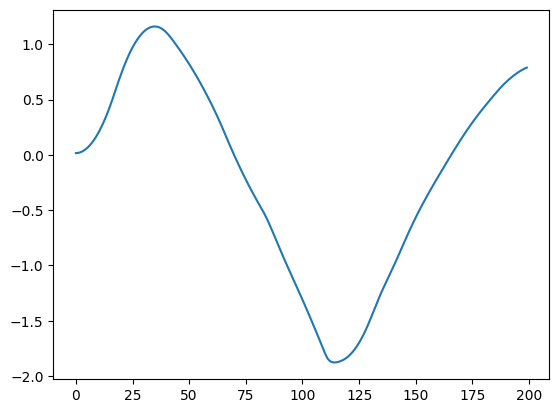

In [64]:
plt.plot(obs_stacked[:, 0])

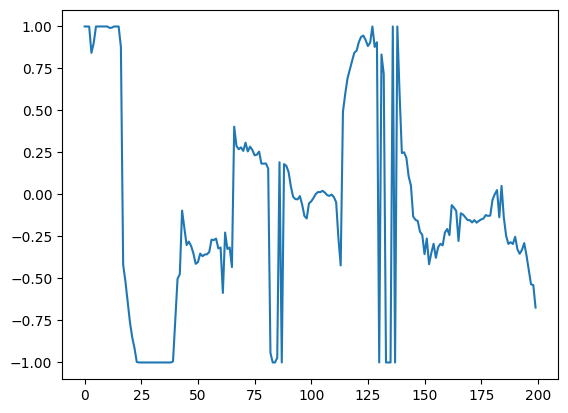

In [67]:
plt.plot(action_stacked[:, 0])

In [47]:
agent.episode_recorder.episode_data['observations'][0].shape

(5,)